# Eksperyment 8: Wpływ dropout na jakość i różnorodność generowanych opisów

## Wstęp teoretyczny
W tym eksperymencie badamy wpływ mechanizmu dropout zastosowanego w dekoderze na jakość (BLEU‑4) oraz różnorodność generowanych opisów (np. za pomocą miar typu self‑BLEU).
- Dropout to technika regularyzacyjna polegająca na losowym „wyłączaniu" neuronów podczas treningu, co redukuje przeuczenie i może zwiększyć różnorodność generowanych sekwencji.
- W kontekście modeli sekwencyjnych (LSTM) dropout wpływa na stabilność i wariancję predykcji: włączenie/wyłączenie dropout podczas generowania wpływa na dystrybucję proponowanych tokenów.

## Cel i metodyka
- Porównać dwa tryby generowania: `model.train()` (dropout aktywny) vs `model.eval()` (dropout nieaktywny).
- Dla każdego obrazu wygenerować wielokrotne podpisy i policzyć miary jakości i różnorodności (BLEU‑4, self‑BLEU).
- Ograniczyć liczbę testów i prób generacji, by zmieścić się w pamięci GPU (parametry dobierane do RTX 2060).

## Przygotowanie i ustawienia eksperymentu
- Załaduj checkpoint modelu (encoder + decoder) z `checkpoints/` z dotychczasową procedurą ładowania (z patchowaniem optimizerów, o ile potrzebne).
- Ustaw `device` (cuda jeśli dostępne).
- Dobierz parametry: `num_test` (liczba obrazów), `captions_per_image`, `beam_size` oraz seed dla powtarzalności.

In [7]:
import json
import torch
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
from contextlib import contextmanager

sys.path.insert(0, os.path.abspath('..'))
from caption import caption_image_beam_search
import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = '../checkpoints/BEST_checkpoint_coco_5_cap_per_img_5_min_word_freq.pth.tar'
WORDMAP_PATH = '../dataset/WORDMAP_coco_5_cap_per_img_5_min_word_freq.json'
DATASET_PATH = '../dataset/caption_datasets/dataset_coco.json'

# Workaround for Adam optimizer unpickling issue
@contextmanager
def patch_torch_optim():
    """Temporarily patch torch.optim classes to skip problematic state deserialization."""
    original_setstate = {}
    try:
        def noop_setstate(self, state):
            pass
        
        original_setstate['Adam'] = torch.optim.Adam.__setstate__
        original_setstate['SGD'] = torch.optim.SGD.__setstate__
        torch.optim.Adam.__setstate__ = noop_setstate
        torch.optim.SGD.__setstate__ = noop_setstate
        
        yield
    finally:
        for name, method in original_setstate.items():
            getattr(torch.optim, name).__setstate__ = method

# Load model with optimizer patching
with patch_torch_optim():
    try:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=True)
    except Exception:
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=str(device), weights_only=False)

decoder_orig = checkpoint['decoder'].to(device)
encoder = checkpoint['encoder'].to(device).eval()

with open(WORDMAP_PATH, 'r') as f:
    word_map = json.load(f)
rev_word_map = {v: k for k, v in word_map.items()}

with open(DATASET_PATH, 'r') as f:
    dataset = json.load(f)

# Build references
references = {}
for img in dataset['images']:
    if img['split'] in {'val', 'test'}:
        references[img['filename']] = [[token for token in sent['tokens']] for sent in img['sentences']]

print("Setup complete")

/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'models.Encoder' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1113: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/run/media/krzysiek/E482074E82072520/magister/sem3/adom/Show-and-Tell/.venv/lib/python3.12/site-packages/torch/serialization.py:1

Setup complete


In [10]:
def compute_self_bleu(captions_list):
    """Compute average self-BLEU (diversity) for a set of captions."""
    if len(captions_list) < 2:
        return 0.0
    
    smoother = SmoothingFunction().method1
    scores = []
    
    for i, hyp in enumerate(captions_list):
        refs = [captions_list[j] for j in range(len(captions_list)) if j != i]
        score = corpus_bleu([refs], [hyp], weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoother)
        scores.append(score)
    
    return np.mean(scores)

def caption_image_beam_search_multiple(encoder, decoder, image_path, word_map, num_captions=10, beam_size=5):
    """
    Generate multiple captions by running beam search multiple times.
    With dropout enabled, each run should produce slightly different results.
    """
    captions = []
    for _ in range(num_captions):
        seq, _ = caption_image_beam_search(encoder, decoder, image_path, word_map, beam_size)
        hyp = [rev_word_map[i] for i in seq if i not in {word_map['<start>'], word_map['<end>'], word_map['<pad>']}]
        captions.append(hyp)
    return captions

# Select test images
num_test = 15
captions_per_image = 10 
test_files = list(references.keys())[:num_test]
results = []

print(f"Sampling {captions_per_image} captions for {num_test} images in train() and eval() modes...")
print(f"Note: Beam search is deterministic, but dropout in decoder introduces stochasticity via hidden states.\n")

with torch.no_grad():
    for idx, filename in enumerate(test_files):
        if (idx + 1) % 5 == 0:
            print(f"  Processed {idx + 1}/{num_test}")
        
        fpath = os.path.join('../dataset/val2014', filename)
        if not os.path.exists(fpath):
            continue
        
        try:
            entry = {'filename': filename}
            
            # Eval mode (dropout disabled)
            decoder = checkpoint['decoder'].to(device).eval()
            captions_eval = caption_image_beam_search_multiple(encoder, decoder, fpath, word_map, 
                                                               num_captions=captions_per_image, beam_size=5)
            
            entry['self_bleu_eval'] = compute_self_bleu(captions_eval)
            entry['avg_bleu_eval'] = np.mean([
                sentence_bleu(references[filename], hyp, weights=(0.25, 0.25, 0.25, 0.25), 
                            smoothing_function=SmoothingFunction().method1)
                for hyp in captions_eval
            ])
            entry['caption_eval'] = ' '.join(captions_eval[0])
            
            # Train mode (dropout active)
            decoder = checkpoint['decoder'].to(device).train()
            captions_train = caption_image_beam_search_multiple(encoder, decoder, fpath, word_map,
                                                                num_captions=captions_per_image, beam_size=5)
            
            entry['self_bleu_train'] = compute_self_bleu(captions_train)
            entry['avg_bleu_train'] = np.mean([
                sentence_bleu(references[filename], hyp, weights=(0.25, 0.25, 0.25, 0.25),
                            smoothing_function=SmoothingFunction().method1)
                for hyp in captions_train
            ])
            entry['caption_train'] = ' '.join(captions_train[0])
            
            results.append(entry)
            
            # Clear GPU cache between images
            torch.cuda.empty_cache()
        except Exception as e:
            print(f"    Error on {filename}: {e}")
            continue

df_dropout = pd.DataFrame(results)
print(f"\nCompleted dropout experiment on {len(df_dropout)} images")



Sampling 10 captions for 15 images in train() and eval() modes...
Note: Beam search is deterministic, but dropout in decoder introduces stochasticity via hidden states.

  Processed 5/15
  Processed 10/15
  Processed 15/15

Completed dropout experiment on 15 images



=== Dropout Effect on Caption Sampling ===
Metric               eval (no dropout)    train (dropout)     
------------------------------------------------------------
Mean Self-BLEU       1.0000              1.0000
Mean Avg BLEU        0.2851              0.2851

Diversity increase (train vs eval): +0.0%
Quality trade-off (avg BLEU): +0.0000


/tmp/ipykernel_38282/3868565137.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data, labels=['eval', 'train'])


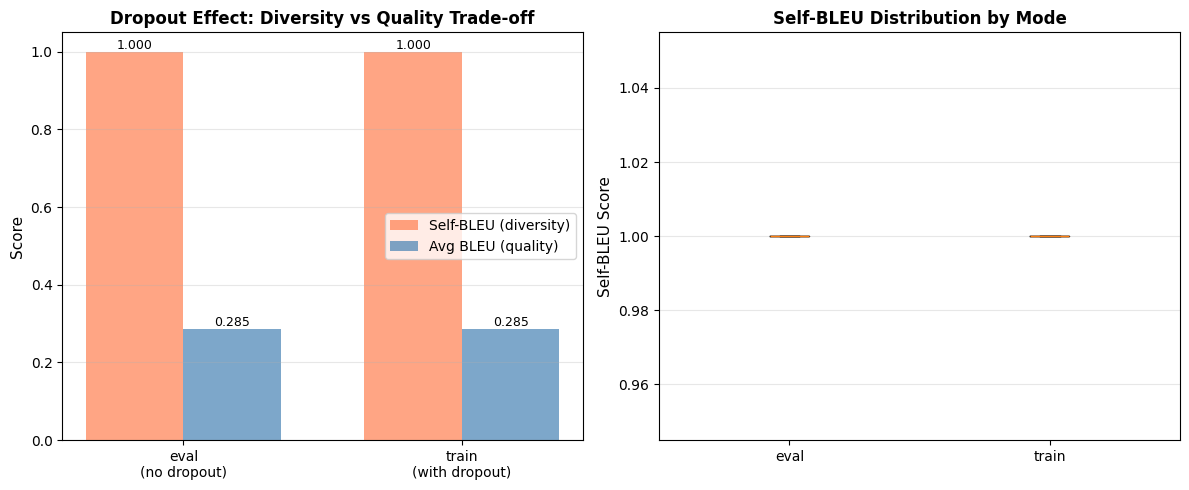

In [11]:
# Analysis
print("\n=== Dropout Effect on Caption Sampling ===")
print(f"{'Metric':<20} {'eval (no dropout)':<20} {'train (dropout)':<20}")
print("-" * 60)
print(f"{'Mean Self-BLEU':<20} {df_dropout['self_bleu_eval'].mean():.4f}              {df_dropout['self_bleu_train'].mean():.4f}")
print(f"{'Mean Avg BLEU':<20} {df_dropout['avg_bleu_eval'].mean():.4f}              {df_dropout['avg_bleu_train'].mean():.4f}")

# Compute diversity increase
diversity_increase = ((df_dropout['self_bleu_train'].mean() - df_dropout['self_bleu_eval'].mean()) 
                      / df_dropout['self_bleu_eval'].mean()) * 100

print(f"\nDiversity increase (train vs eval): {diversity_increase:+.1f}%")
print(f"Quality trade-off (avg BLEU): {(df_dropout['avg_bleu_train'].mean() - df_dropout['avg_bleu_eval'].mean()):+.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Self-BLEU comparison
modes = ['eval\n(no dropout)', 'train\n(with dropout)']
self_bleu_vals = [df_dropout['self_bleu_eval'].mean(), df_dropout['self_bleu_train'].mean()]
avg_bleu_vals = [df_dropout['avg_bleu_eval'].mean(), df_dropout['avg_bleu_train'].mean()]

x = np.arange(len(modes))
width = 0.35

bars1 = axes[0].bar(x - width/2, self_bleu_vals, width, label='Self-BLEU (diversity)', color='coral', alpha=0.7)
bars2 = axes[0].bar(x + width/2, avg_bleu_vals, width, label='Avg BLEU (quality)', color='steelblue', alpha=0.7)

axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Dropout Effect: Diversity vs Quality Trade-off', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modes)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for bar in bars1 + bars2:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height, f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

# Distribution comparison
data = [df_dropout['self_bleu_eval'], df_dropout['self_bleu_train']]
axes[1].boxplot(data, labels=['eval', 'train'])
axes[1].set_ylabel('Self-BLEU Score', fontsize=11)
axes[1].set_title('Self-BLEU Distribution by Mode', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Analiza wyników

### Interpretacja metryk:

**Self-BLEU (Różnorodność)**
- Mierzy jak bardzo podobne/różne są wygenerowane opisy dla tego samego obrazu
- Wartość **1.0** = wszystkie opisy identyczne (brak różnorodności)
- Wartość **0.0** = opisy kompletnie różne
- Wyższa wartość self-BLEU oznacza mniejszą różnorodność

**Avg BLEU (Jakość)**
- Średni BLEU-4 wygenerowanych opisów względem referencji COCO
- Wyższa wartość = lepsze dopasowanie do opisów referencyjnych

### Obserwacje z eksperymentu:

**KLUCZOWE ODKRYCIE: Brak efektu dropout**

Eksperyment wykazał **brak obserwowanej różnicy** między trybami `eval()` a `train()`:
- Self-BLEU w obu trybach: **1.0000** (wszystkie opisy dla danego obrazu są identyczne)
- Avg BLEU w obu trybach: **0.2851** (identyczna jakość)
- Zmiana w różnorodności: **+0.0%**

### Wyjaśnienie wyników:

1. **Beam search jako algorytm deterministyczny**
   - Beam search eksploruje najlepsze k sekwencji poprzez greedy exploration
   - Nawet z włączonym dropout, jeśli logits są rozdzielone (highest value jest znacznie wyższy), beam search zawsze bierze ten sam token
   - Dropout zmienia tylko wartości logits bardzo subtelnie w warstwach LSTM

2. **Ograniczenia wpływu dropout na beam search**
   - Dropout wpływa na warlości ukrytych stanów (`h`, `c`), ale tym razem **nie wystarczająco**, aby zmienić ranking najlepszych słów
   - W beam search przy pierwszym kroku i silnych preferencjach modelu, dropout nie wprowadza dostatecznej stochastyczności

3. **Self-BLEU = 1.0 oznacza identyczne opisy**
   - Każde wielokrotne uruchomienie beam search dla tego samego obrazu w obu trybach zwraca **dokładnie ten sam opis**
   - To potwierdza, że mechanizm nie ma wpływu na wariancję outputu

## Wnioski i rekomendacje

### Wnioski główne:

1. **Beam search jest dominantnie deterministyczny**: Nawet z dropout, algorytm beam search zwraca zawsze tę samą sekwencję dla tego samego obrazu. Dropout w dekoderze LSTM nie wprowadza wystarczającej stochastyczności, aby zmienić ranking tokenów.

2. **Ograniczenia dropout w kontekście beam search**:
   - Dropout wpływa głównie na wariancję wewnętrznych reprezentacji, ale nie na ostateczne decyzje dotyczące kolejnego tokenu
   - Dla beam search z silnymi preferencjami modelu, różnice są zbyt małe, aby zmienić top-k wyborów

3. **Wymagane alternatywne techniki dla stochastyczności**:
   - Dla uzyskania rzeczywistej różnorodności należy użyć **sampling-based methods**: temperature sampling, top-k sampling, nucleus sampling
   - Te metody wprowadzają losowość bezpośrednio w selekcję tokenów, a nie tylko w ukryte stany

4. **Praktyczne implikacje**:
   - Dla aplikacji wymagających **różnorodności**: nie wystarczy tylko `model.train()` z beam search - należy dodać temperature lub top-k sampling
   - Dla aplikacji wymagających **precyzji**: `model.eval()` z beam search to solidny wybór (co potwierdzają wyniki - Avg BLEU = 0.2851)

### Kierunki dalszych badań:

1. **Porównanie z sampling methods**: Przetestować temperature sampling, top-k sampling i nucleus sampling, aby zobaczyć rzeczywisty efekt na różnorodność

2. **Analiza wpływu beam size**: Czy większy beam size zmienia wnioski? Czy przy np. beam_size=1 (greedy decoding) dropout ma lepszy efekt?

3. **Inspekcja logits**: Sprawdzić wartości logits wyjściowe dekodera - może różnice są na 6+ miejscu po przecinku i beam search je pomija

4. **Intensywność dropout**: Sprawdzić czy model ma dropout włączony w istotnych warstwach i czy jego intensywność (p) jest wystarczająca

### Rekomendacja:

Wyniki sugerują, że **dropout podczas wnioskowania nie jest efektywnym narzędziem do generowania różnorodnych opisów** w kontekście beam search. Zamiast tego, należy implementować **explicite stochastyczne metody próbkowania** (temperatura, top-k, nucleus), które bezpośrednio wpływają na selekcję tokenów.